# Deepfake Detection — Model Training & Evaluation

**This notebook picks up right where `data_pipeline_optimized.ipynb` left off.**
Make sure `dataset_config.json` and the `04_dataset/` folder are in the same
directory as this notebook before running.

## What this notebook does
```
Section 1  — Install & Import Libraries
Section 2  — Load Config & Rebuild DataLoaders
Section 3  — Build the Model  (EfficientNet-B0 + Transfer Learning)
Section 4  — Experiment 1: Baseline Training
Section 5  — Experiment 2: Fine-Tuning with Lower Learning Rate
Section 6  — Compare Experiments & Pick the Best Model
Section 7  — Full Evaluation  (Accuracy, Confusion Matrix, ROC / AUC)
Section 8  — Video-Level Prediction  (frame votes → video verdict)
Section 9  — Grad-CAM Visualisation  (what does the model look at?)
Section 10 — Save All Results
```

---
## Section 1: Install & Import Libraries

In [1]:
# Install grad-cam — the only library not included in a standard PyTorch setup
# grad-cam lets us visualise which pixels caused the model's decision
%pip install grad-cam scikit-learn --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ── Standard library ─────────────────────────────────────────────────────
import json
import copy
import random
from pathlib import Path
from collections import defaultdict

# ── Third-party ───────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm.notebook import tqdm

# ── PyTorch ───────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

# ── Evaluation metrics ────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    classification_report,
)

# ── Grad-CAM ──────────────────────────────────────────────────────────────
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ── Device setup ─────────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Fix the random seed so results are reproducible every time we re-run
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('All libraries imported successfully.')
print(f'   PyTorch version : {torch.__version__}')
print(f'   Device          : {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU             : {torch.cuda.get_device_name(0)}')

All libraries imported successfully.
   PyTorch version : 2.13.0.dev20260506+cu130
   Device          : cuda
   GPU             : NVIDIA GeForce RTX 5060


---
## Section 2: Load Config & Rebuild DataLoaders

We read all the settings from `dataset_config.json` instead of hard-coding
numbers. This way, if Person A ever reprocesses the data with different
settings, we only need to update the JSON file — nothing else changes.

In [3]:
# ── Load the config file saved by the data pipeline ──────────────────────
CONFIG_PATH = Path('dataset_config.json')
assert CONFIG_PATH.exists(), (
    f'Cannot find {CONFIG_PATH}. '
    'Make sure dataset_config.json is in the same folder as this notebook.'
)

with open(CONFIG_PATH) as f:
    cfg = json.load(f)

DATASET_DIR   = Path(cfg['dataset_dir'])
IMAGE_SIZE    = cfg['image_size']          # 224
BATCH_SIZE    = cfg['batch_size']          # 32
NUM_WORKERS   = cfg['num_workers']         # 0 on Windows
CLASS_TO_IDX  = cfg['class_to_idx']        # {'fake': 0, 'real': 1}
IDX_TO_CLASS  = {v: k for k, v in CLASS_TO_IDX.items()}
IMAGENET_MEAN = cfg['imagenet_mean']
IMAGENET_STD  = cfg['imagenet_std']
NUM_CLASSES   = len(CLASS_TO_IDX)          # 2

print('Config loaded.')
print(f'   Dataset folder : {DATASET_DIR}')
print(f'   Image size     : {IMAGE_SIZE}x{IMAGE_SIZE}')
print(f'   Batch size     : {BATCH_SIZE}')
print(f'   Classes        : {CLASS_TO_IDX}')
print(f'   Train images   : {cfg["split_sizes"]["train"]}')
print(f'   Val images     : {cfg["split_sizes"]["val"]}')
print(f'   Test images    : {cfg["split_sizes"]["test"]}')

Config loaded.
   Dataset folder : C:\Users\lulum\Documents\umbc\DATA 621\Final Project\04_dataset
   Image size     : 224x224
   Batch size     : 32
   Classes        : {'fake': 0, 'real': 1}
   Train images   : 57501
   Val images     : 12141
   Test images    : 12410


In [4]:
# ── Rebuild the DataLoaders ───────────────────────────────────────────────
# We need to recreate these here because DataLoaders cannot be saved to disk.

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(root=str(DATASET_DIR / 'train'),
                                     transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=str(DATASET_DIR / 'val'),
                                     transform=eval_transforms)
test_dataset  = datasets.ImageFolder(root=str(DATASET_DIR / 'test'),
                                     transform=eval_transforms)

pin = (DEVICE == 'cuda')
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=pin)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=pin)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=pin)

print('DataLoaders ready.')
print(f'   Train batches : {len(train_loader)}')
print(f'   Val batches   : {len(val_loader)}')
print(f'   Test batches  : {len(test_loader)}')

DataLoaders ready.
   Train batches : 1797
   Val batches   : 380
   Test batches  : 388


---
## Section 3: Build the Model

### Why EfficientNet-B0?
EfficientNet-B0 was designed to be accurate *and* efficient at the same time.
It uses a method called **compound scaling** — instead of just making the network
deeper (more layers) OR wider (more neurons), it scales all three dimensions
(depth, width, resolution) together in a balanced way.

Compared to ResNet-50:
- **5× fewer parameters** (5.3M vs 25M) → trains faster and uses less VRAM
- **Better accuracy** on ImageNet (77.1% vs 76.1%)
- Perfect size for a class project: fast enough to experiment with, strong enough to get good results

### Transfer Learning Strategy
EfficientNet-B0 was already trained on ImageNet (1.2 million images, 1000 classes).
It already knows how to detect edges, textures, and shapes. We just need to teach
it the difference between real and fake faces.

We use a **two-phase** approach:
1. **Experiment 1 (Baseline):** Freeze all layers except the final classifier.
   Only the new head learns. Fast, but limited.
2. **Experiment 2 (Fine-tuning):** Unfreeze the last few blocks and train with
   a very small learning rate. The whole network adapts.

In [5]:
def build_model(num_classes: int = 2, freeze_backbone: bool = True) -> nn.Module:
    """
    Build an EfficientNet-B0 model adapted for binary deepfake classification.

    Architecture changes from the original EfficientNet-B0:
      - The final fully-connected layer is replaced with:
          Dropout(0.3)  →  Linear(1280, 2)
      - Dropout reduces overfitting by randomly zeroing neurons during training.

    Args:
        num_classes     : Number of output classes (2: fake and real).
        freeze_backbone : If True, only the final classifier layer is trainable.
                          If False, the entire network is trainable (fine-tuning).

    Returns:
        The modified EfficientNet-B0 model moved to DEVICE.
    """
    # Load EfficientNet-B0 with ImageNet pretrained weights
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        # Freeze all layers — none of them will be updated during training
        for param in model.parameters():
            param.requires_grad = False

    # Replace the original classifier head (outputs 1000 classes)
    # with a new one that outputs 2 classes.
    # model.classifier is a Sequential([Dropout, Linear(1280, 1000)])
    in_features = model.classifier[1].in_features  # 1280 for EfficientNet-B0

    model.classifier = nn.Sequential(
        # Dropout: randomly sets 30% of neurons to zero during training.
        # This forces the model to learn more robust features.
        nn.Dropout(p=0.3, inplace=True),

        # The new output layer: 1280 inputs → 2 outputs (fake, real)
        nn.Linear(in_features, num_classes),
    )

    # New layers are trainable regardless of freeze_backbone
    for param in model.classifier.parameters():
        param.requires_grad = True

    return model.to(DEVICE)


# ── Quick sanity check: make sure the output shape is correct ────────────
test_model  = build_model(num_classes=NUM_CLASSES, freeze_backbone=True)
dummy_input = torch.zeros(2, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
dummy_out   = test_model(dummy_input)

assert dummy_out.shape == (2, NUM_CLASSES), \
    f'Expected shape (2, {NUM_CLASSES}), got {dummy_out.shape}'

total_params    = sum(p.numel() for p in test_model.parameters())
trainable_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)

print('Model architecture is correct!')
print(f'   Total parameters     : {total_params:,}')
print(f'   Trainable parameters : {trainable_params:,}')
print(f'   Frozen parameters    : {total_params - trainable_params:,}')

del test_model, dummy_input, dummy_out

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\lulum/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|█████████████████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:00<00:00, 37.3MB/s]


Model architecture is correct!
   Total parameters     : 4,010,110
   Trainable parameters : 2,562
   Frozen parameters    : 4,007,548


In [6]:
# ── Print the classifier head so we can see the architecture ─────────────
# This is the part we changed. The backbone (features) is unchanged from EfficientNet.
preview_model = build_model(NUM_CLASSES, freeze_backbone=True)

print('=== EfficientNet-B0 Architecture (key parts) ===')
print()
print('[Backbone — frozen pretrained layers]')
print('  features[0]  : Conv2d  3 → 32,  stride=2  (first stem layer)')
print('  features[1-8]: MBConv blocks (mobile inverted bottleneck)')
print('  features[8]  : Conv2d  320 → 1280  (final feature expansion)')
print()
print('[Pooling]')
print('  AdaptiveAvgPool2d → output: (1280,)')
print()
print('[Classifier head — OUR NEW LAYERS — trainable]')
print(preview_model.classifier)
print()
print('[Output]')
print(f'  Logits shape: (batch_size, {NUM_CLASSES})')
print(f'  Index 0 = {IDX_TO_CLASS[0].upper()},  Index 1 = {IDX_TO_CLASS[1].upper()}')

del preview_model

=== EfficientNet-B0 Architecture (key parts) ===

[Backbone — frozen pretrained layers]
  features[0]  : Conv2d  3 → 32,  stride=2  (first stem layer)
  features[1-8]: MBConv blocks (mobile inverted bottleneck)
  features[8]  : Conv2d  320 → 1280  (final feature expansion)

[Pooling]
  AdaptiveAvgPool2d → output: (1280,)

[Classifier head — OUR NEW LAYERS — trainable]
Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)

[Output]
  Logits shape: (batch_size, 2)
  Index 0 = FAKE,  Index 1 = REAL


---
## Section 4: Experiment 1 — Baseline Training

**Strategy:** Freeze the backbone. Only the new classifier head trains.

| Hyperparameter | Value | Reason |
|---|---|---|
| Loss function | CrossEntropyLoss | Standard choice for multi-class classification |
| Optimizer | Adam | Adapts learning rate per parameter; converges faster than SGD |
| Learning rate | 1e-3 | Good starting LR when only the head is training |
| LR scheduler | ReduceLROnPlateau | Halves the LR if val accuracy stops improving for 2 epochs |
| Dropout | 0.3 | Prevents the small head from memorising training data |
| Epochs | 10 | Enough for the head to converge without running for hours |

In [7]:
def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer | None,
    is_training: bool,
) -> tuple[float, float]:
    """
    Run one full pass through the dataset (either training or validation).

    During training  (is_training=True):
      - model.train() is set so dropout and batchnorm behave normally
      - gradients are computed and the optimizer updates the weights

    During validation (is_training=False):
      - model.eval() disables dropout so predictions are deterministic
      - torch.no_grad() skips gradient computation to save memory

    Args:
        model       : The neural network.
        loader      : DataLoader providing batches of (images, labels).
        criterion   : The loss function.
        optimizer   : The optimizer (None during validation).
        is_training : Whether this is a training or evaluation pass.

    Returns:
        A tuple of (average_loss, accuracy_percentage).
    """
    if is_training:
        model.train()
    else:
        model.eval()

    total_loss    = 0.0
    correct_preds = 0
    total_samples = 0

    # torch.no_grad() tells PyTorch not to store gradients during validation.
    # This roughly halves the memory usage during evaluation.
    context = torch.enable_grad() if is_training else torch.no_grad()

    with context:
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            if is_training:
                optimizer.zero_grad()      # Clear gradients from the last batch

            logits = model(images)         # Forward pass
            loss   = criterion(logits, labels)

            if is_training:
                loss.backward()            # Compute gradients
                optimizer.step()           # Update weights

            # Track loss and accuracy
            total_loss    += loss.item() * images.size(0)
            preds          = logits.argmax(dim=1)
            correct_preds += (preds == labels).sum().item()
            total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    accuracy = correct_preds / total_samples * 100
    return avg_loss, accuracy


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_epochs: int,
    learning_rate: float,
    save_path: str,
) -> dict:
    """
    Full training loop with validation, LR scheduling, and early stopping.

    The model weights with the best validation accuracy are saved to disk
    at save_path so we can reload them later.

    Args:
        model         : The neural network to train.
        train_loader  : DataLoader for training data.
        val_loader    : DataLoader for validation data.
        num_epochs    : Maximum number of training epochs.
        learning_rate : Initial learning rate for the optimizer.
        save_path     : File path where the best model weights are saved.

    Returns:
        A dictionary with the full training history (loss and accuracy per epoch).
    """
    # CrossEntropyLoss combines LogSoftmax + NLLLoss in one step.
    # It is the standard loss for classification problems.
    criterion = nn.CrossEntropyLoss()

    # Adam adapts the learning rate for each parameter individually.
    # weight_decay adds L2 regularisation to help prevent overfitting.
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate,
        weight_decay=1e-4,
    )

    # ReduceLROnPlateau: if val_accuracy does not improve for 2 epochs,
    # multiply the learning rate by 0.5.
    # This lets the model do a finer search once progress slows down.
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',        # We want val_accuracy to go UP
        factor=0.5,        # New LR = old LR × 0.5
        patience=2,        # Wait 2 epochs before reducing
    )

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss'  : [], 'val_acc'  : [],
    }
    best_val_acc = 0.0

    for epoch in range(1, num_epochs + 1):
        current_lr = optimizer.param_groups[0]['lr']

        # ── Training pass ────────────────────────────────────────────────
        train_loss, train_acc = run_epoch(
            model, train_loader, criterion, optimizer, is_training=True)

        # ── Validation pass ───────────────────────────────────────────────
        val_loss, val_acc = run_epoch(
            model, val_loader, criterion, None, is_training=False)

        # ── Learning rate scheduler step ─────────────────────────────────
        scheduler.step(val_acc)

        # ── Save best model ───────────────────────────────────────────────
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            # deep copy the weights so later epochs don't overwrite this
            torch.save(copy.deepcopy(model.state_dict()), save_path)

        # ── Record history ────────────────────────────────────────────────
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch:>2}/{num_epochs}  '
              f'Train: loss={train_loss:.4f} acc={train_acc:.2f}%  '
              f'Val: loss={val_loss:.4f} acc={val_acc:.2f}%  '
              f'LR: {current_lr:.2e}'
              + ('  ← best' if val_acc == best_val_acc else ''))

    print(f'\nTraining done. Best val accuracy: {best_val_acc:.2f}%')
    print(f'Best weights saved to: {save_path}')
    return history


print('Training helper functions are ready.')

Training helper functions are ready.


In [8]:
# ── Run Experiment 1 ─────────────────────────────────────────────────────
# Frozen backbone: only the 2-layer classifier head trains

EXP1_SAVE_PATH = 'exp1_best_model.pth'
EXP1_EPOCHS    = 10
EXP1_LR        = 1e-3

print('=== Experiment 1: Baseline (Frozen Backbone) ===')
print(f'   Epochs         : {EXP1_EPOCHS}')
print(f'   Learning rate  : {EXP1_LR}')
print(f'   Trainable layers: classifier head only')
print()

model_exp1   = build_model(num_classes=NUM_CLASSES, freeze_backbone=True)
history_exp1 = train_model(
    model=model_exp1,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=EXP1_EPOCHS,
    learning_rate=EXP1_LR,
    save_path=EXP1_SAVE_PATH,
)

=== Experiment 1: Baseline (Frozen Backbone) ===
   Epochs         : 10
   Learning rate  : 0.001
   Trainable layers: classifier head only

Epoch  1/10  Train: loss=0.3087 acc=88.53%  Val: loss=0.3078 acc=88.56%  LR: 1.00e-03  ← best
Epoch  2/10  Train: loss=0.2980 acc=88.84%  Val: loss=0.3149 acc=87.93%  LR: 1.00e-03
Epoch  3/10  Train: loss=0.2920 acc=88.97%  Val: loss=0.2963 acc=88.31%  LR: 1.00e-03
Epoch  4/10  Train: loss=0.2926 acc=88.85%  Val: loss=0.3212 acc=87.65%  LR: 1.00e-03
Epoch  5/10  Train: loss=0.2852 acc=89.15%  Val: loss=0.3002 acc=88.42%  LR: 5.00e-04
Epoch  6/10  Train: loss=0.2867 acc=88.95%  Val: loss=0.2962 acc=88.32%  LR: 5.00e-04
Epoch  7/10  Train: loss=0.2855 acc=89.10%  Val: loss=0.2859 acc=88.75%  LR: 5.00e-04  ← best
Epoch  8/10  Train: loss=0.2853 acc=89.18%  Val: loss=0.3023 acc=88.33%  LR: 5.00e-04
Epoch  9/10  Train: loss=0.2855 acc=89.12%  Val: loss=0.2943 acc=88.19%  LR: 5.00e-04
Epoch 10/10  Train: loss=0.2857 acc=89.10%  Val: loss=0.2920 acc=88.4

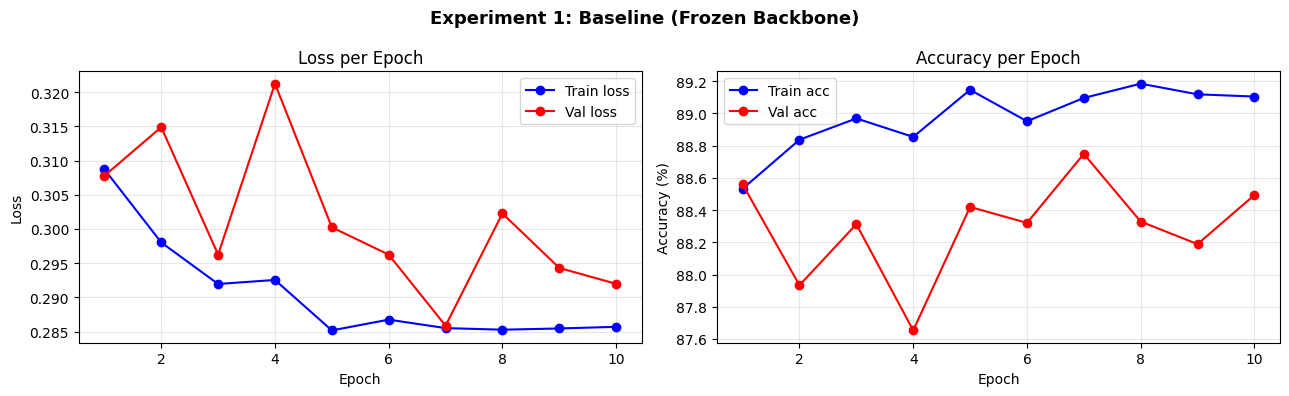

Chart saved to: exp1_training_curves.png


In [9]:
def plot_training_history(history: dict, title: str, save_path: str) -> None:
    """
    Plot training and validation loss + accuracy curves side by side.

    These curves help us see whether the model is overfitting (train goes up
    but val stays flat or goes down) or still learning (both go up together).
    """
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train loss')
    axes[0].plot(epochs, history['val_loss'],   'r-o', label='Val loss')
    axes[0].set_title('Loss per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train acc')
    axes[1].plot(epochs, history['val_acc'],   'r-o', label='Val acc')
    axes[1].set_title('Accuracy per Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f'Chart saved to: {save_path}')


plot_training_history(
    history_exp1,
    title='Experiment 1: Baseline (Frozen Backbone)',
    save_path='exp1_training_curves.png',
)

---
## Section 5: Experiment 2 — Fine-Tuning with Lower Learning Rate

**Strategy:** Unfreeze the last two blocks of the backbone and use a much smaller
learning rate (1e-4 instead of 1e-3). This lets the network adapt its deeper
feature detectors to face-specific patterns.

**Why a lower LR for fine-tuning?**
The backbone already has good weights from ImageNet training. A large LR would
destroy those weights (called "catastrophic forgetting"). A small LR makes tiny
adjustments, keeping the useful features while adapting to the new task.

In [10]:
def unfreeze_last_n_blocks(model: nn.Module, n: int = 2) -> nn.Module:
    """
    Unfreeze the last N feature blocks of EfficientNet-B0 for fine-tuning.

    EfficientNet-B0 has 9 feature blocks (features[0] to features[8]).
    Unfreezing only the last few blocks gives a good trade-off:
    - Earlier blocks detect basic shapes and textures → keep them frozen
    - Later blocks detect face-specific features → let them adapt

    Args:
        model : The EfficientNet-B0 model (must have .features attribute).
        n     : Number of feature blocks to unfreeze from the end.

    Returns:
        The same model with the requested layers unfrozen.
    """
    # First, make sure everything is frozen (clean start)
    for param in model.parameters():
        param.requires_grad = False

    # Then unfreeze the last n feature blocks
    feature_blocks = list(model.features.children())
    for block in feature_blocks[-n:]:
        for param in block.parameters():
            param.requires_grad = True

    # Always keep the classifier head trainable
    for param in model.classifier.parameters():
        param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'Unfroze last {n} blocks. Trainable: {trainable:,} / {total:,} params.')
    return model


print('unfreeze_last_n_blocks() is ready.')

unfreeze_last_n_blocks() is ready.


In [11]:
# ── Run Experiment 2 ─────────────────────────────────────────────────────
# We start from Exp 1's best weights to save time

EXP2_SAVE_PATH = 'exp2_best_model.pth'
EXP2_EPOCHS    = 10
EXP2_LR        = 1e-4    # 10× smaller than Exp 1

print('=== Experiment 2: Fine-Tuning (Unfrozen Last 2 Blocks) ===')
print(f'   Starting from  : {EXP1_SAVE_PATH} (Exp 1 best weights)')
print(f'   Epochs         : {EXP2_EPOCHS}')
print(f'   Learning rate  : {EXP2_LR}  (10x smaller than Exp 1)')
print()

# Load the best weights from Experiment 1 as the starting point
model_exp2 = build_model(num_classes=NUM_CLASSES, freeze_backbone=True)
model_exp2.load_state_dict(torch.load(EXP1_SAVE_PATH, map_location=DEVICE))

# Unfreeze the last 2 backbone blocks for fine-tuning
model_exp2 = unfreeze_last_n_blocks(model_exp2, n=2)
print()

history_exp2 = train_model(
    model=model_exp2,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=EXP2_EPOCHS,
    learning_rate=EXP2_LR,
    save_path=EXP2_SAVE_PATH,
)

=== Experiment 2: Fine-Tuning (Unfrozen Last 2 Blocks) ===
   Starting from  : exp1_best_model.pth (Exp 1 best weights)
   Epochs         : 10
   Learning rate  : 0.0001  (10x smaller than Exp 1)

Unfroze last 2 blocks. Trainable: 1,131,954 / 4,010,110 params.

Epoch  1/10  Train: loss=0.2219 acc=91.37%  Val: loss=0.2154 acc=91.08%  LR: 1.00e-04  ← best
Epoch  2/10  Train: loss=0.1698 acc=93.32%  Val: loss=0.1871 acc=92.36%  LR: 1.00e-04  ← best
Epoch  3/10  Train: loss=0.1478 acc=94.19%  Val: loss=0.1817 acc=92.35%  LR: 1.00e-04
Epoch  4/10  Train: loss=0.1328 acc=94.85%  Val: loss=0.1721 acc=92.92%  LR: 1.00e-04  ← best
Epoch  5/10  Train: loss=0.1221 acc=95.15%  Val: loss=0.1585 acc=93.64%  LR: 1.00e-04  ← best
Epoch  6/10  Train: loss=0.1143 acc=95.59%  Val: loss=0.1557 acc=93.85%  LR: 1.00e-04  ← best
Epoch  7/10  Train: loss=0.1079 acc=95.88%  Val: loss=0.1539 acc=93.86%  LR: 1.00e-04  ← best
Epoch  8/10  Train: loss=0.1021 acc=96.04%  Val: loss=0.1610 acc=93.49%  LR: 1.00e-04
Ep

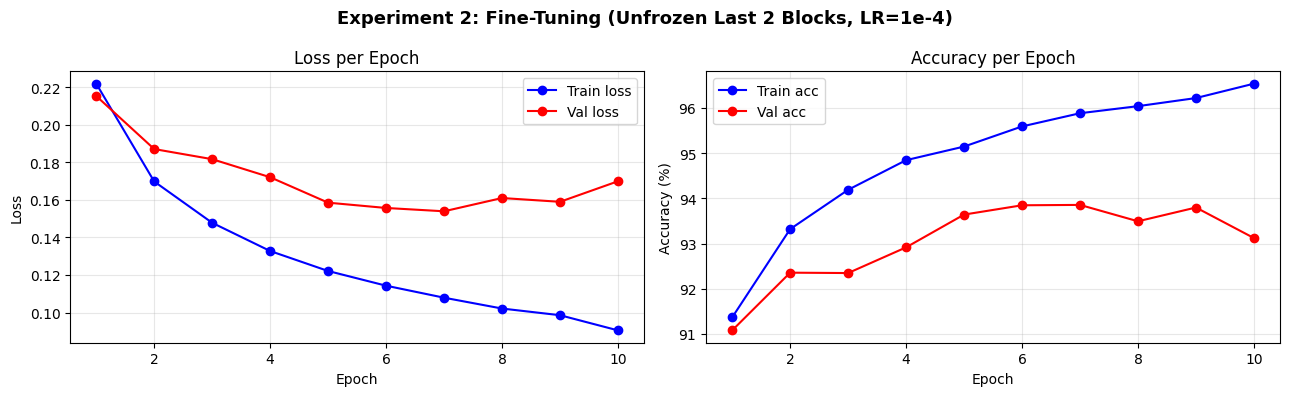

Chart saved to: exp2_training_curves.png


In [12]:
plot_training_history(
    history_exp2,
    title='Experiment 2: Fine-Tuning (Unfrozen Last 2 Blocks, LR=1e-4)',
    save_path='exp2_training_curves.png',
)

---
## Section 6: Compare Experiments & Pick the Best Model

In [13]:
best_exp1_val = max(history_exp1['val_acc'])
best_exp2_val = max(history_exp2['val_acc'])

print('=== Experiment Comparison ===')
print(f'   Exp 1 (frozen backbone,   LR=1e-3): best val acc = {best_exp1_val:.2f}%')
print(f'   Exp 2 (fine-tuned 2 blks, LR=1e-4): best val acc = {best_exp2_val:.2f}%')

if best_exp2_val >= best_exp1_val:
    BEST_MODEL_PATH = EXP2_SAVE_PATH
    best_history    = history_exp2
    winning_exp     = 'Experiment 2'
else:
    BEST_MODEL_PATH = EXP1_SAVE_PATH
    best_history    = history_exp1
    winning_exp     = 'Experiment 1'

print(f'\n→ Using {winning_exp} ({BEST_MODEL_PATH}) for final evaluation.')

=== Experiment Comparison ===
   Exp 1 (frozen backbone,   LR=1e-3): best val acc = 88.75%
   Exp 2 (fine-tuned 2 blks, LR=1e-4): best val acc = 93.86%

→ Using Experiment 2 (exp2_best_model.pth) for final evaluation.


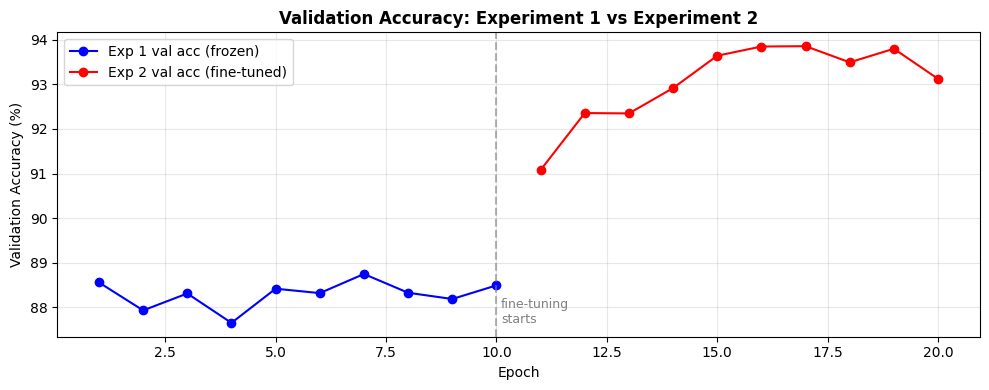

Comparison chart saved.


In [14]:
# ── Side-by-side val accuracy comparison ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

epochs_e1 = range(1, len(history_exp1['val_acc']) + 1)
epochs_e2 = range(
    len(history_exp1['val_acc']) + 1,
    len(history_exp1['val_acc']) + len(history_exp2['val_acc']) + 1,
)

ax.plot(epochs_e1, history_exp1['val_acc'], 'b-o', label='Exp 1 val acc (frozen)')
ax.plot(epochs_e2, history_exp2['val_acc'], 'r-o', label='Exp 2 val acc (fine-tuned)')

# Mark where fine-tuning started
ax.axvline(x=max(epochs_e1), color='gray', linestyle='--', alpha=0.6)
ax.text(max(epochs_e1) + 0.1, min(history_exp1['val_acc']),
        'fine-tuning\nstarts', fontsize=9, color='gray')

ax.set_title('Validation Accuracy: Experiment 1 vs Experiment 2', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy (%)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiment_comparison.png', dpi=150)
plt.show()
print('Comparison chart saved.')

---
## Section 7: Full Evaluation on the Test Set

We now load the best model and run it on the **test set** — the split that
was never touched during training or validation.

We measure four things:
- **Accuracy** — percentage of images classified correctly
- **Confusion Matrix** — shows exactly which mistakes the model makes
- **Classification Report** — precision, recall, and F1 per class
- **AUC / ROC Curve** — measures quality of the model's confidence scores

In [15]:
def evaluate_on_test_set(
    model: nn.Module,
    loader: DataLoader,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Run the model on the entire test set and collect predictions.

    Args:
        model  : The trained neural network (in eval mode).
        loader : DataLoader for the test split.

    Returns:
        Three numpy arrays:
          all_labels  — ground truth class indices
          all_preds   — predicted class indices
          all_probs   — predicted probability of being class 1 (real)
    """
    model.eval()
    all_labels = []
    all_preds  = []
    all_probs  = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Evaluating on test set'):
            images = images.to(DEVICE)
            logits = model(images)

            # Softmax converts raw logits into probabilities (sum to 1)
            probs = torch.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)

            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())
            # We only need the probability of class 1 (real) for the ROC curve
            all_probs.extend(probs[:, 1].cpu().numpy())

    return (
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probs),
    )


# ── Load best model weights and evaluate ─────────────────────────────────
best_model = build_model(num_classes=NUM_CLASSES, freeze_backbone=False)
best_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))

test_labels, test_preds, test_probs = evaluate_on_test_set(best_model, test_loader)

accuracy = accuracy_score(test_labels, test_preds) * 100
auc      = roc_auc_score(test_labels, test_probs)

print(f'\n=== Test Set Results ===')
print(f'   Accuracy : {accuracy:.2f}%')
print(f'   AUC      : {auc:.4f}  (1.0 is perfect, 0.5 is random guessing)')

Evaluating on test set:   0%|          | 0/388 [00:00<?, ?it/s]


=== Test Set Results ===
   Accuracy : 93.27%
   AUC      : 0.9573  (1.0 is perfect, 0.5 is random guessing)


In [16]:
# ── Detailed classification report ───────────────────────────────────────
class_names = [IDX_TO_CLASS[i] for i in sorted(IDX_TO_CLASS)]
report = classification_report(test_labels, test_preds, target_names=class_names)

print('=== Classification Report ===')
print(report)
print()
print('Metric definitions:')
print('  Precision : of all frames the model called FAKE, what fraction was actually fake?')
print('  Recall    : of all actual FAKE frames, what fraction did the model catch?')
print('  F1-score  : harmonic mean of precision and recall')

=== Classification Report ===
              precision    recall  f1-score   support

        fake       0.96      0.96      0.96     10902
        real       0.72      0.73      0.72      1508

    accuracy                           0.93     12410
   macro avg       0.84      0.84      0.84     12410
weighted avg       0.93      0.93      0.93     12410


Metric definitions:
  Precision : of all frames the model called FAKE, what fraction was actually fake?
  Recall    : of all actual FAKE frames, what fraction did the model catch?
  F1-score  : harmonic mean of precision and recall


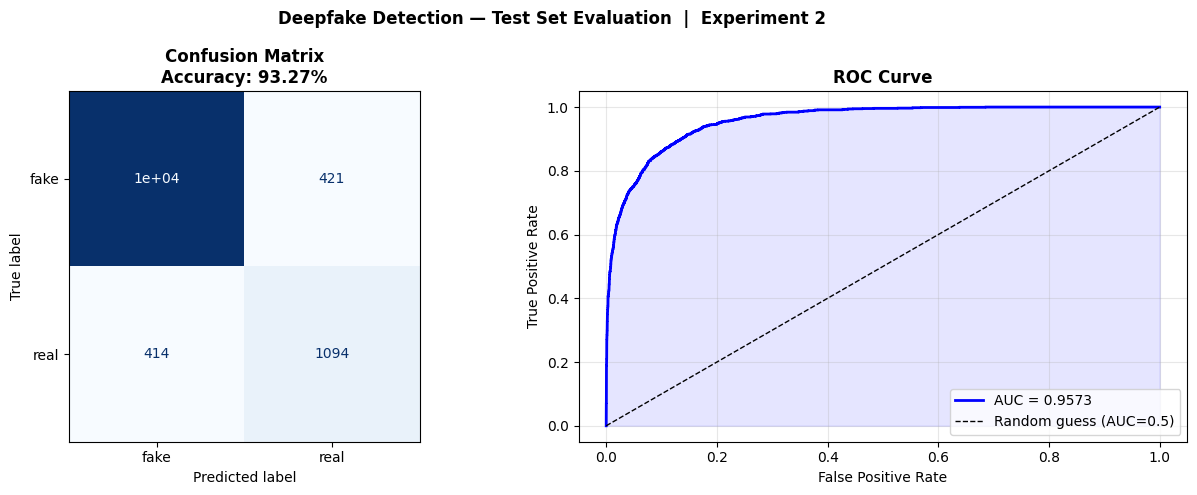

Evaluation chart saved.


In [17]:
# ── Confusion matrix and ROC curve side by side ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: confusion matrix
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(
    f'Confusion Matrix\nAccuracy: {accuracy:.2f}%',
    fontweight='bold',
)

# Right: ROC curve
fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random guess (AUC=0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='blue')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    f'Deepfake Detection — Test Set Evaluation  |  {winning_exp}',
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
plt.savefig('test_evaluation.png', dpi=150)
plt.show()
print('Evaluation chart saved.')

---
## Section 8: Video-Level Prediction

So far every prediction is for a **single frame** (one image).
But in the real world, we want to say "this entire VIDEO is a deepfake" — not
just "this one frame looks fake".

**Strategy — majority vote:**
We group all the frames from the same video, count how many frames the model
predicted as fake vs. real, and let the majority win.
For example, if a video has 20 frames and the model says 15 are fake and 5 are
real, we call the whole video fake.

In [18]:
def get_video_level_predictions(
    dataset: datasets.ImageFolder,
    frame_preds: np.ndarray,
    frame_labels: np.ndarray,
) -> tuple[list, list, list]:
    """
    Aggregate per-frame predictions into per-video predictions.

    The file naming convention from the data pipeline is:
        04_dataset/test/fake/video_001__frame_0000.jpg
    The video name is the part before '__'.

    We group all frames from the same video and use majority vote:
    if more frames are predicted fake than real, the video is fake.

    Args:
        dataset      : The ImageFolder dataset (gives us file paths).
        frame_preds  : Model predictions for each frame (0=fake, 1=real).
        frame_labels : Ground truth labels for each frame.

    Returns:
        Three lists: (video_names, video_labels, video_preds)
    """
    # Build a dict: video_name → list of (label, pred) for each frame
    video_data = defaultdict(lambda: {'labels': [], 'preds': []})

    for i, (file_path, _) in enumerate(dataset.samples):
        file_name  = Path(file_path).stem        # e.g. 'video_001__frame_0000'
        video_name = file_name.split('__')[0]    # e.g. 'video_001'
        video_data[video_name]['labels'].append(int(frame_labels[i]))
        video_data[video_name]['preds'].append(int(frame_preds[i]))

    video_names  = []
    video_labels = []
    video_preds  = []

    for video_name, data in sorted(video_data.items()):
        # Ground truth: all frames of the same video have the same label
        true_label = data['labels'][0]

        # Majority vote: if more than half of frames are predicted real, call it real
        vote_real = sum(data['preds'])
        vote_fake = len(data['preds']) - vote_real
        final_pred = 1 if vote_real > vote_fake else 0  # 1=real, 0=fake

        video_names.append(video_name)
        video_labels.append(true_label)
        video_preds.append(final_pred)

    return video_names, video_labels, video_preds


video_names, video_labels, video_preds = get_video_level_predictions(
    test_dataset, test_preds, test_labels,
)

video_labels_arr = np.array(video_labels)
video_preds_arr  = np.array(video_preds)
video_accuracy   = accuracy_score(video_labels_arr, video_preds_arr) * 100

print('=== Video-Level Accuracy ===')
print(f'   Frame-level accuracy : {accuracy:.2f}%  ({len(test_labels)} frames)')
print(f'   Video-level accuracy : {video_accuracy:.2f}%  ({len(video_labels)} videos)')
print()
print(classification_report(video_labels_arr, video_preds_arr, target_names=class_names))

=== Video-Level Accuracy ===
   Frame-level accuracy : 93.27%  (12410 frames)
   Video-level accuracy : 97.77%  (224 videos)

              precision    recall  f1-score   support

        fake       0.98      1.00      0.99       200
        real       1.00      0.79      0.88        24

    accuracy                           0.98       224
   macro avg       0.99      0.90      0.94       224
weighted avg       0.98      0.98      0.98       224



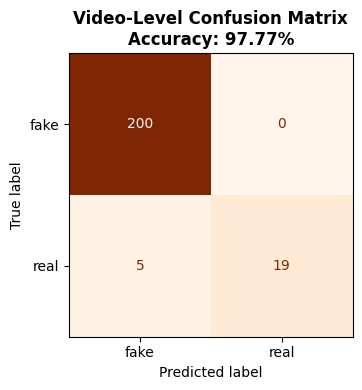

Video-level chart saved.


In [19]:
# ── Video-level confusion matrix ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm_video = confusion_matrix(video_labels_arr, video_preds_arr)
ConfusionMatrixDisplay(cm_video, display_labels=class_names).plot(
    ax=ax, colorbar=False, cmap='Oranges',
)
ax.set_title(f'Video-Level Confusion Matrix\nAccuracy: {video_accuracy:.2f}%',
             fontweight='bold')
plt.tight_layout()
plt.savefig('video_level_evaluation.png', dpi=150)
plt.show()
print('Video-level chart saved.')

---
## Section 9: Grad-CAM Visualisation

**Grad-CAM** (Gradient-weighted Class Activation Mapping) answers the question:
*"Which pixels did the model look at to make its decision?"*

It works by measuring how much each feature map in the last convolutional layer
contributes to the final prediction. Areas that contribute a lot are shown in
warm colours (red/orange). Areas that contribute little are shown in cool colours
(blue/green).

For deepfake faces, we typically see the model focusing on:
- Eye edges and eyelashes (GAN artifacts are common here)
- The hairline boundary (hard for GANs to generate cleanly)
- The mouth region (subtle blending errors)

In [21]:
def get_gradcam_heatmap(
    model: nn.Module,
    image_tensor: torch.Tensor,
    target_class: int,
) -> np.ndarray:
    """
    Generate a Grad-CAM heatmap for one image and a given target class.

    We use the last convolutional layer of the backbone (features[8][0]) as
    the target layer. This layer has the most semantic information.

    Args:
        model        : The trained EfficientNet-B0.
        image_tensor : A single normalised image tensor of shape (1, 3, H, W).
        target_class : The class index we want the heatmap for.

    Returns:
        A numpy array of shape (H, W) with values in [0, 1].
    """
    # The last conv block in EfficientNet-B0 is features[8][0]
    target_layer = [model.features[8][0]]

    with GradCAM(model=model, target_layers=target_layer) as cam:
        targets = [ClassifierOutputTarget(target_class)]
        heatmap = cam(input_tensor=image_tensor, targets=targets)[0]

    return heatmap  # shape: (H, W), values in [0, 1]


def denormalise_tensor(tensor: torch.Tensor) -> np.ndarray:
    """
    Reverse ImageNet normalisation and convert a tensor to a uint8 numpy array.

    Args:
        tensor : Image tensor of shape (3, H, W) with normalised values.

    Returns:
        Numpy array of shape (H, W, 3) with uint8 values in [0, 255].
    """
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img  = (tensor.cpu() * std + mean).clamp(0, 1)
    return (img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)


print('Grad-CAM helper functions are ready.')

Grad-CAM helper functions are ready.


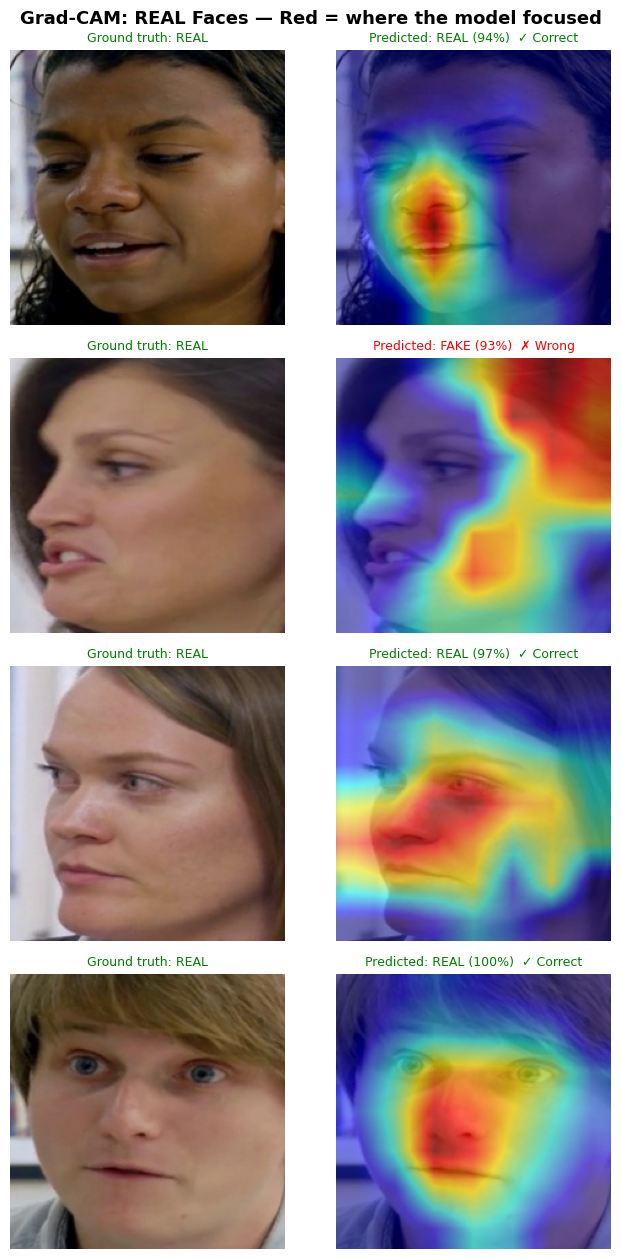

Grad-CAM figure saved to: gradcam_real.png


In [22]:
def show_gradcam_grid(
    model: nn.Module,
    dataset: datasets.ImageFolder,
    label_filter: int,
    n_samples: int = 4,
    title: str = '',
    save_path: str = 'gradcam.png',
) -> None:
    """
    Display a grid of Grad-CAM heatmaps for a given class (real or fake).

    Each row shows: original face | heatmap overlay | prediction label

    Args:
        model        : Trained model (must be in eval mode).
        dataset      : ImageFolder to sample images from.
        label_filter : Only sample images with this ground truth label.
        n_samples    : Number of example images to show.
        title        : Title for the entire figure.
        save_path    : File path where the figure is saved.
    """
    model.eval()

    # Collect indices of images belonging to the requested class
    candidate_indices = [
        i for i, (_, lbl) in enumerate(dataset.samples)
        if lbl == label_filter
    ]
    chosen = random.sample(candidate_indices, min(n_samples, len(candidate_indices)))

    fig, axes = plt.subplots(n_samples, 2, figsize=(7, 3.2 * n_samples))
    if n_samples == 1:
        axes = np.expand_dims(axes, 0)

    fig.suptitle(title, fontsize=13, fontweight='bold')

    for row, idx in enumerate(chosen):
        # Load the image as a tensor
        image_tensor, true_label = dataset[idx]
        input_tensor = image_tensor.unsqueeze(0).to(DEVICE)  # add batch dim

        # Get the model's prediction for this image
        with torch.no_grad():
            logits      = model(input_tensor)
            pred_class  = int(logits.argmax(dim=1).item())
            confidence  = torch.softmax(logits, dim=1)[0][pred_class].item()

        # Generate the Grad-CAM heatmap for the predicted class
        heatmap      = get_gradcam_heatmap(model, input_tensor, pred_class)
        original_img = denormalise_tensor(image_tensor)

        # Overlay the heatmap on the original image
        # show_cam_on_image expects float32 in [0, 1]
        overlay = show_cam_on_image(
            original_img.astype(np.float32) / 255.0,
            heatmap,
            use_rgb=True,
        )

        # Column 0: original face
        axes[row, 0].imshow(original_img)
        axes[row, 0].set_title(
            f'Ground truth: {IDX_TO_CLASS[true_label].upper()}',
            fontsize=9,
            color='green' if IDX_TO_CLASS[true_label] == 'real' else 'red',
        )
        axes[row, 0].axis('off')

        # Column 1: heatmap overlay
        axes[row, 1].imshow(overlay)
        correct_str = '✓ Correct' if pred_class == true_label else '✗ Wrong'
        axes[row, 1].set_title(
            f'Predicted: {IDX_TO_CLASS[pred_class].upper()} '
            f'({confidence:.0%})  {correct_str}',
            fontsize=9,
            color='green' if pred_class == true_label else 'red',
        )
        axes[row, 1].axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Grad-CAM figure saved to: {save_path}')


# ── Show Grad-CAM for real faces ──────────────────────────────────────────
show_gradcam_grid(
    model=best_model,
    dataset=test_dataset,
    label_filter=CLASS_TO_IDX['real'],
    n_samples=4,
    title='Grad-CAM: REAL Faces — Red = where the model focused',
    save_path='gradcam_real.png',
)

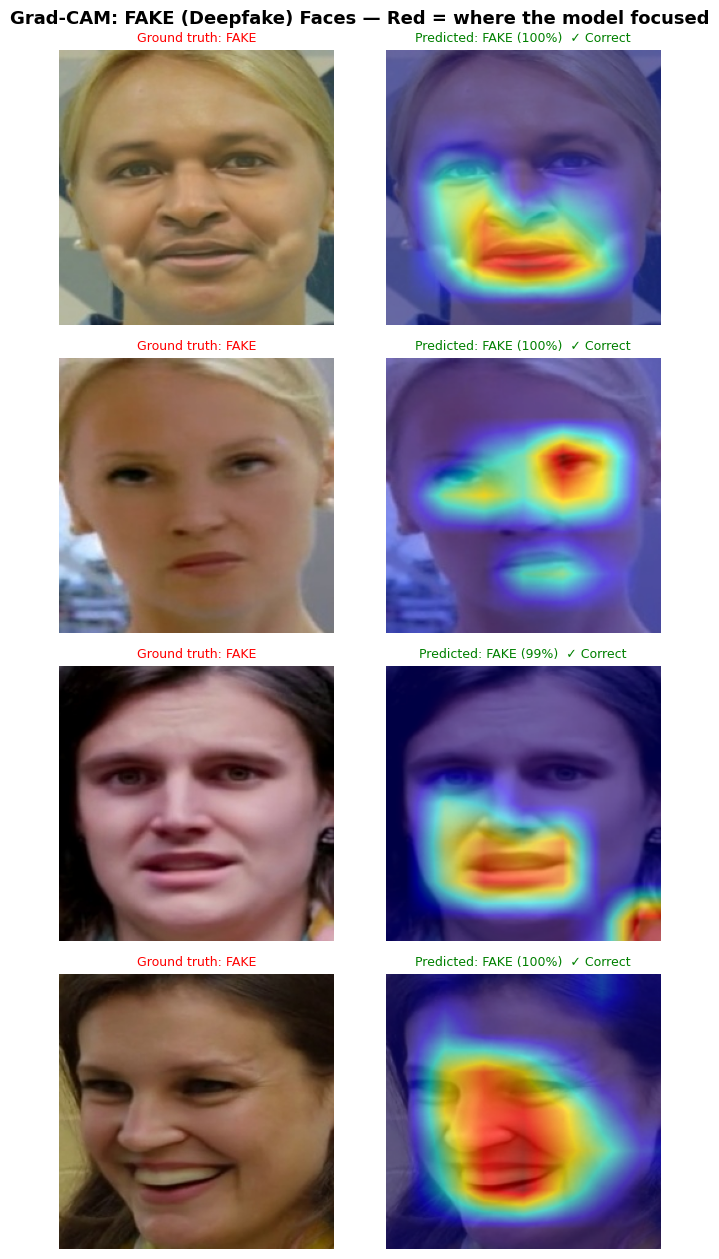

Grad-CAM figure saved to: gradcam_fake.png


In [23]:
# ── Show Grad-CAM for fake faces ──────────────────────────────────────────
show_gradcam_grid(
    model=best_model,
    dataset=test_dataset,
    label_filter=CLASS_TO_IDX['fake'],
    n_samples=4,
    title='Grad-CAM: FAKE (Deepfake) Faces — Red = where the model focused',
    save_path='gradcam_fake.png',
)

---
## Section 10: Save All Results

In [24]:
# ── Save the final model as best_model.pth for reproducibility ───────────
import shutil
shutil.copy(BEST_MODEL_PATH, 'best_model.pth')

# ── Save all numeric results to a JSON file ───────────────────────────────
results = {
    'winning_experiment'    : winning_exp,
    'best_model_file'       : 'best_model.pth',
    'frame_level': {
        'accuracy_pct'      : round(accuracy, 4),
        'auc'               : round(float(auc), 4),
        'total_frames'      : int(len(test_labels)),
        'correct_frames'    : int(np.sum(test_labels == test_preds)),
    },
    'video_level': {
        'accuracy_pct'      : round(video_accuracy, 4),
        'total_videos'      : int(len(video_labels)),
        'correct_videos'    : int(np.sum(video_labels_arr == video_preds_arr)),
    },
    'hyperparameters': {
        'exp1_lr'           : EXP1_LR,
        'exp1_epochs'       : EXP1_EPOCHS,
        'exp2_lr'           : EXP2_LR,
        'exp2_epochs'       : EXP2_EPOCHS,
        'dropout'           : 0.3,
        'weight_decay'      : 1e-4,
        'lr_scheduler'      : 'ReduceLROnPlateau (factor=0.5, patience=2)',
        'loss_function'     : 'CrossEntropyLoss',
        'optimizer'         : 'Adam',
    },
    'training_history': {
        'exp1'              : history_exp1,
        'exp2'              : history_exp2,
    },
}

with open('model_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('=' * 55)
print('  All done!')
print('=' * 55)
print()
print('Files produced by this notebook:')
print('  best_model.pth            ← trained model weights')
print('  model_results.json        ← all metrics and hyperparameters')
print('  exp1_training_curves.png  ← Exp 1 loss/accuracy charts')
print('  exp2_training_curves.png  ← Exp 2 loss/accuracy charts')
print('  experiment_comparison.png ← Exp 1 vs Exp 2 val accuracy')
print('  test_evaluation.png       ← confusion matrix + ROC curve')
print('  video_level_evaluation.png← video-level confusion matrix')
print('  gradcam_real.png          ← Grad-CAM heatmaps for real faces')
print('  gradcam_fake.png          ← Grad-CAM heatmaps for fake faces')
print()
print(f'  Frame-level accuracy : {accuracy:.2f}%')
print(f'  Video-level accuracy : {video_accuracy:.2f}%')
print(f'  AUC score            : {auc:.4f}')

  All done!

Files produced by this notebook:
  best_model.pth            ← trained model weights
  model_results.json        ← all metrics and hyperparameters
  exp1_training_curves.png  ← Exp 1 loss/accuracy charts
  exp2_training_curves.png  ← Exp 2 loss/accuracy charts
  experiment_comparison.png ← Exp 1 vs Exp 2 val accuracy
  test_evaluation.png       ← confusion matrix + ROC curve
  video_level_evaluation.png← video-level confusion matrix
  gradcam_real.png          ← Grad-CAM heatmaps for real faces
  gradcam_fake.png          ← Grad-CAM heatmaps for fake faces

  Frame-level accuracy : 93.27%
  Video-level accuracy : 97.77%
  AUC score            : 0.9573
